In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [74]:
# read in table
df = pd.read_csv("nsw_features_added.csv")
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df = df.sort_values("DATETIME").reset_index(drop=True)

df.head()

,DATETIME,TOTALDEMAND,REGIONID,LOCATION,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,month,day,radiation,is_public_holiday,is_school_term,day_of_week
0,2010-01-01 00:00:00,8038.00,NSW1,Bankstown,23.1,7999.11,7811.86,7822.38,2010,1,1,14.6,True,False,Friday
1,2010-01-01 00:30:00,7809.31,NSW1,Bankstown,22.9,7596.21,7612.63,7715.68,2010,1,1,14.6,True,False,Friday
2,2010-01-01 01:00:00,7483.69,NSW1,Bankstown,22.6,7380.70,7339.64,7482.56,2010,1,1,14.6,True,False,Friday
3,2010-01-01 01:30:00,7117.23,NSW1,Bankstown,22.5,7022.05,7009.55,7129.32,2010,1,1,14.6,True,False,Friday
4,2010-01-01 02:00:00,6812.03,NSW1,Bankstown,22.5,6682.92,6683.15,6800.73,2010,1,1,14.6,True,False,Friday


In [75]:
# REGIONID/LOCATION are constant, no predictive value. day (of month) isn't a meaningful demand driver either
df = df.drop(columns=["REGIONID", "LOCATION", "day"])

df.head()

,DATETIME,TOTALDEMAND,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,month,radiation,is_public_holiday,is_school_term,day_of_week
0,2010-01-01 00:00:00,8038.00,23.1,7999.11,7811.86,7822.38,2010,1,14.6,True,False,Friday
1,2010-01-01 00:30:00,7809.31,22.9,7596.21,7612.63,7715.68,2010,1,14.6,True,False,Friday
2,2010-01-01 01:00:00,7483.69,22.6,7380.70,7339.64,7482.56,2010,1,14.6,True,False,Friday
3,2010-01-01 01:30:00,7117.23,22.5,7022.05,7009.55,7129.32,2010,1,14.6,True,False,Friday
4,2010-01-01 02:00:00,6812.03,22.5,6682.92,6683.15,6800.73,2010,1,14.6,True,False,Friday


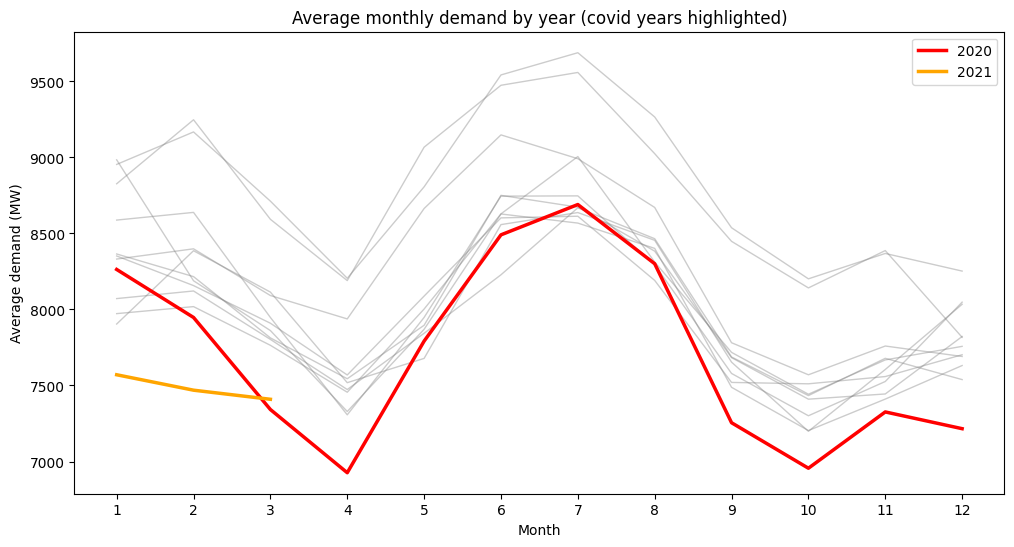

In [76]:
# just checking if should drop covid, i bleive so it is disporportionately lower

monthly_year = df.groupby([df["DATETIME"].dt.year.rename("year"), df["DATETIME"].dt.month.rename("month")])["TOTALDEMAND"].mean().reset_index()
pivot = monthly_year.pivot(index="month", columns="year", values="TOTALDEMAND")

plt.figure(figsize=(12, 6))
for year in pivot.columns:
    if year == 2020:
        plt.plot(pivot.index, pivot[year], color="red", linewidth=2.5, label=str(year))
    elif year == 2021:
        plt.plot(pivot.index, pivot[year], color="orange", linewidth=2.5, label=str(year))
    else:
        plt.plot(pivot.index, pivot[year], color="gray", alpha=0.4, linewidth=1)

plt.title("Average monthly demand by year (covid years highlighted)")
plt.xlabel("Month")
plt.ylabel("Average demand (MW)")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

In [77]:
# laggy tempeartuer, raditaion and demand by 1 day
# 1 day before is our proxy for as live data as possible

lagged = df[["DATETIME", "TEMPERATURE", "radiation", "TOTALDEMAND"]].copy()
lagged["DATETIME"] = lagged["DATETIME"] + pd.Timedelta(days=1)
lagged = lagged.rename(columns={
    "TEMPERATURE": "temperature_day_before",
    "radiation": "radiation_day_before",
    "TOTALDEMAND": "demand_day_before",
})

df = df.merge(lagged, on="DATETIME", how="left")

df[["DATETIME", "TEMPERATURE", "temperature_day_before", "radiation", "radiation_day_before", "TOTALDEMAND", "demand_day_before"]].head()

,DATETIME,TEMPERATURE,temperature_day_before,radiation,radiation_day_before,TOTALDEMAND,demand_day_before
0,2010-01-01 00:00:00,23.1,NaN,14.6,NaN,8038.00,NaN
1,2010-01-01 00:30:00,22.9,NaN,14.6,NaN,7809.31,NaN
2,2010-01-01 01:00:00,22.6,NaN,14.6,NaN,7483.69,NaN
3,2010-01-01 01:30:00,22.5,NaN,14.6,NaN,7117.23,NaN
4,2010-01-01 02:00:00,22.5,NaN,14.6,NaN,6812.03,NaN


In [78]:
# dropping the first day 2010-01-01 as technically it will be null for temperature 
df = df.dropna(subset=["temperature_day_before", "radiation_day_before", "demand_day_before"]).reset_index(drop=True)

df.shape

(196465, 15)

In [79]:
# adding this as for most of our models a one hot encoded day of week will be helpful

df = pd.get_dummies(df, columns=["day_of_week"], prefix="day")

df.head()

,DATETIME,TOTALDEMAND,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,month,radiation,is_public_holiday,...,temperature_day_before,radiation_day_before,demand_day_before,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,2010-01-02 00:00:00,7574.85,24.0,7427.88,7187.48,7269.95,2010,1,18.4,False,...,23.1,14.6,8038.00,False,False,True,False,False,False,False
1,2010-01-02 00:30:00,7343.30,24.3,7224.98,7201.30,7208.39,2010,1,18.4,False,...,22.9,14.6,7809.31,False,False,True,False,False,False,False
2,2010-01-02 01:00:00,7099.73,24.2,6969.69,6974.06,6968.42,2010,1,18.4,False,...,22.6,14.6,7483.69,False,False,True,False,False,False,False
3,2010-01-02 01:30:00,6779.80,24.2,6843.15,6627.91,6628.73,2010,1,18.4,False,...,22.5,14.6,7117.23,False,False,True,False,False,False,False
4,2010-01-02 02:00:00,6497.47,24.1,6514.63,6327.21,6324.71,2010,1,18.4,False,...,22.5,14.6,6812.03,False,False,True,False,False,False,False


In [80]:
# one hot encode hour of day, this ias day of hour is not lienarly related to demand

df["hour"] = df["DATETIME"].dt.hour
df = pd.get_dummies(df, columns=["hour"], prefix="hour")

df.head()

,DATETIME,TOTALDEMAND,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,month,radiation,is_public_holiday,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2010-01-02 00:00:00,7574.85,24.0,7427.88,7187.48,7269.95,2010,1,18.4,False,...,False,False,False,False,False,False,False,False,False,False
1,2010-01-02 00:30:00,7343.30,24.3,7224.98,7201.30,7208.39,2010,1,18.4,False,...,False,False,False,False,False,False,False,False,False,False
2,2010-01-02 01:00:00,7099.73,24.2,6969.69,6974.06,6968.42,2010,1,18.4,False,...,False,False,False,False,False,False,False,False,False,False
3,2010-01-02 01:30:00,6779.80,24.2,6843.15,6627.91,6628.73,2010,1,18.4,False,...,False,False,False,False,False,False,False,False,False,False
4,2010-01-02 02:00:00,6497.47,24.1,6514.63,6327.21,6324.71,2010,1,18.4,False,...,False,False,False,False,False,False,False,False,False,False


In [81]:
# one hot encode month too, same reasoning as hour/day of week, not linear with demand
df = pd.get_dummies(df, columns=["month"], prefix="month")

df.head()

,DATETIME,TOTALDEMAND,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,radiation,is_public_holiday,is_school_term,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2010-01-02 00:00:00,7574.85,24.0,7427.88,7187.48,7269.95,2010,18.4,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2010-01-02 00:30:00,7343.30,24.3,7224.98,7201.30,7208.39,2010,18.4,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2010-01-02 01:00:00,7099.73,24.2,6969.69,6974.06,6968.42,2010,18.4,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2010-01-02 01:30:00,6779.80,24.2,6843.15,6627.91,6628.73,2010,18.4,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2010-01-02 02:00:00,6497.47,24.1,6514.63,6327.21,6324.71,2010,18.4,False,False,...,False,False,False,False,False,False,False,False,False,False


In [82]:
## Train / validation / test split

train = df[df["year"] <= 2017].copy()
validation = df[df["year"] == 2018].copy()
test = df[df["year"] == 2019].copy()

print(train.shape, validation.shape, test.shape)
print(train["year"].min(), train["year"].max())
print(validation["year"].unique())
print(test["year"].unique())

# dropping year now the split is done, not useful/risky as a feature since test years are outside train's range
train = train.drop(columns=["year"])
validation = validation.drop(columns=["year"])
test = test.drop(columns=["year"])

(140208, 56) (17520, 56) (17520, 56)
2010 2017
[2018]
[2019]


In [83]:
# standard scaling some of these features 
# typicalyl scaling is harmless, it also means models can converge quicker and also 
# acts a form of regularisation. 

scale_cols = [
    "TEMPERATURE",
    "temperature_day_before",
    "forecast_closest",
    "forecast_12hr_prior",
    "forecast_dayprior",
    "radiation",
    "radiation_day_before",
    "demand_day_before",
]

scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols]).round(4)
validation[scale_cols] = scaler.transform(validation[scale_cols]).round(4)
test[scale_cols] = scaler.transform(test[scale_cols]).round(4)

train.head()

,DATETIME,TOTALDEMAND,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,radiation,is_public_holiday,is_school_term,temperature_day_before,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2010-01-02 00:00:00,7574.85,1.1329,-0.6028,-0.7672,-0.7031,0.3444,False,False,0.9784,...,False,False,False,False,False,False,False,False,False,False
1,2010-01-02 00:30:00,7343.30,1.1844,-0.7573,-0.7567,-0.7495,0.3444,False,False,0.9441,...,False,False,False,False,False,False,False,False,False,False
2,2010-01-02 01:00:00,7099.73,1.1672,-0.9516,-0.9281,-0.9301,0.3444,False,False,0.8927,...,False,False,False,False,False,False,False,False,False,False
3,2010-01-02 01:30:00,6779.80,1.1672,-1.0480,-1.1890,-1.1859,0.3444,False,False,0.8755,...,False,False,False,False,False,False,False,False,False,False
4,2010-01-02 02:00:00,6497.47,1.1501,-1.2981,-1.4157,-1.4148,0.3444,False,False,0.8755,...,False,False,False,False,False,False,False,False,False,False


In [84]:
# converting True/False and one hot columns to 0/1 ints
bool_cols = ["is_public_holiday", "is_school_term"] + [c for c in df.columns if c.startswith("day_") or c.startswith("hour_") or c.startswith("month_")]

for frame in (train, validation, test):
    frame[bool_cols] = frame[bool_cols].astype(int)

train.to_csv("nsw_train.csv", index=False)
validation.to_csv("nsw_validation.csv", index=False)
test.to_csv("nsw_test.csv", index=False) 

In [85]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140208 entries, 0 to 140207
Data columns (total 55 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   DATETIME                140208 non-null  datetime64[ns]
 1   TOTALDEMAND             140208 non-null  float64       
 2   TEMPERATURE             140208 non-null  float64       
 3   forecast_closest        140208 non-null  float64       
 4   forecast_12hr_prior     140208 non-null  float64       
 5   forecast_dayprior       140208 non-null  float64       
 6   radiation               140208 non-null  float64       
 7   is_public_holiday       140208 non-null  int64         
 8   is_school_term          140208 non-null  int64         
 9   temperature_day_before  140208 non-null  float64       
 10  radiation_day_before    140208 non-null  float64       
 11  demand_day_before       140208 non-null  float64       
 12  day_Friday              140208 non-